In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

In [2]:
salary=[-30, -20, 4, 5, 6, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 60, 75]

In [3]:
salary

[-30,
 -20,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 10,
 11,
 12,
 13,
 14,
 15,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 60,
 75]

In [4]:
np.quantile(salary,[0,0.25,0.50,0.75,1])

array([-30.  ,   9.25,  15.  ,  21.75,  75.  ])

In [5]:
 df=pd.DataFrame(salary,columns=['Salary'])

In [6]:
df

,Salary
0,-30
1,-20
2,4
3,5
4,6
5,7
6,8
7,9
8,10
9,10


In [7]:
df.describe()

,Salary
count,30.000000
mean,16.066667
std,18.589825
min,-30.000000
25%,9.250000
50%,15.000000
75%,21.750000
max,75.000000


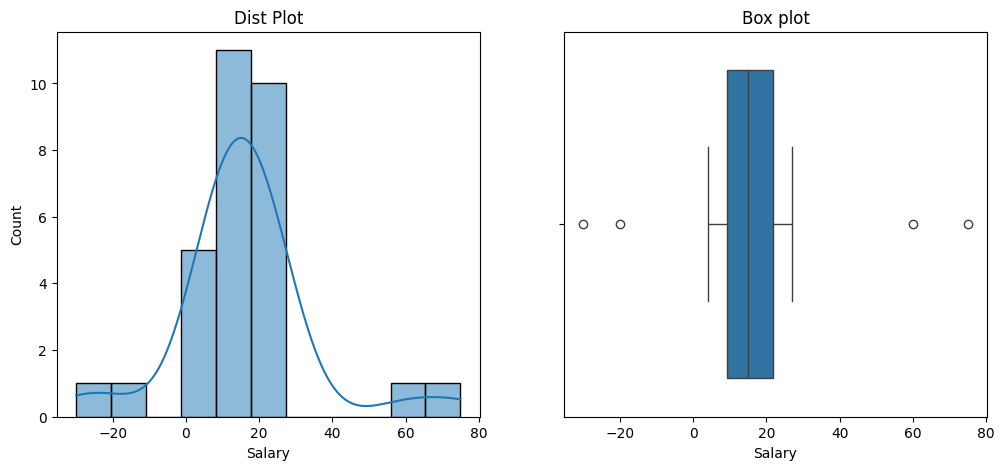

In [8]:
# To check outliers >> distplot,boxplot

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Salary'],kde=True)
plt.title("Dist Plot")

plt.subplot(1,2,2)
sns.boxplot(data=df,x='Salary')
plt.title('Box plot')
plt.show()

In [9]:
#>> Droping the Outlier
Q1=df['Salary'].quantile(0.25)
Q3=df['Salary'].quantile(0.75)

IQR=Q3-Q1

Lower_fence=Q1-1.5*IQR
Upper_fence=Q3+1.5*IQR
df_filtered=df[(df.Salary >= Lower_fence ) & (df.Salary <= Upper_fence)]

In [10]:
df.shape

(30, 1)

In [11]:
df_filtered.shape

(26, 1)

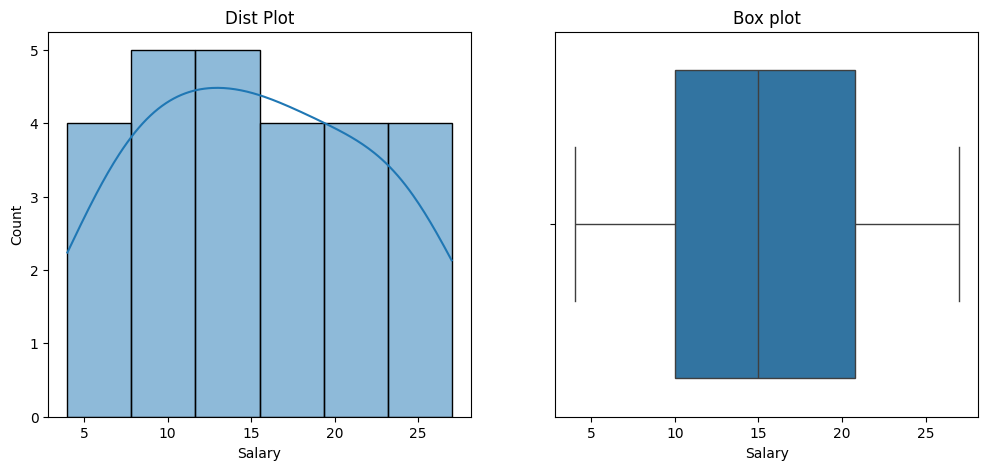

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_filtered['Salary'],kde=True)
plt.title('Dist Plot')

plt.subplot(1,2,2)
sns.boxplot(data=df_filtered,x='Salary')
plt.title('Box plot')
plt.show()

In [13]:
# Imputation with mean and median
df['Salary_imputed_mean']=np.where((df.Salary >= Upper_fence) | (df.Salary <= Lower_fence), df['Salary'].mean(),df['Salary'])

In [14]:
df

,Salary,Salary_imputed_mean
0,-30,16.066667
1,-20,16.066667
2,4,4.000000
3,5,5.000000
4,6,6.000000
5,7,7.000000
6,8,8.000000
7,9,9.000000
8,10,10.000000
9,10,10.000000


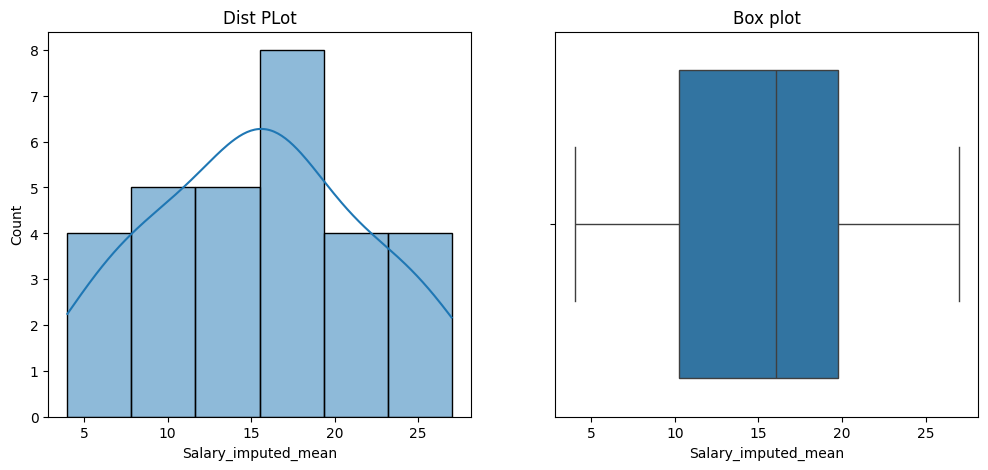

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Salary_imputed_mean'],kde=True)
plt.title('Dist PLot')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='Salary_imputed_mean')
plt.title('Box plot')
plt.show()

In [19]:
# Using median
df['Imputed_Salary_median']=np.where((df.Salary >= Upper_fence) | (df.Salary <= Lower_fence),df['Salary'].median(),df['Salary'] )            

In [17]:
df

,Salary,Salary_imputed_mean,Imputed_Salary_median
0,-30,16.066667,15.0
1,-20,16.066667,15.0
2,4,4.000000,4.0
3,5,5.000000,5.0
4,6,6.000000,6.0
5,7,7.000000,7.0
6,8,8.000000,8.0
7,9,9.000000,9.0
8,10,10.000000,10.0
9,10,10.000000,10.0


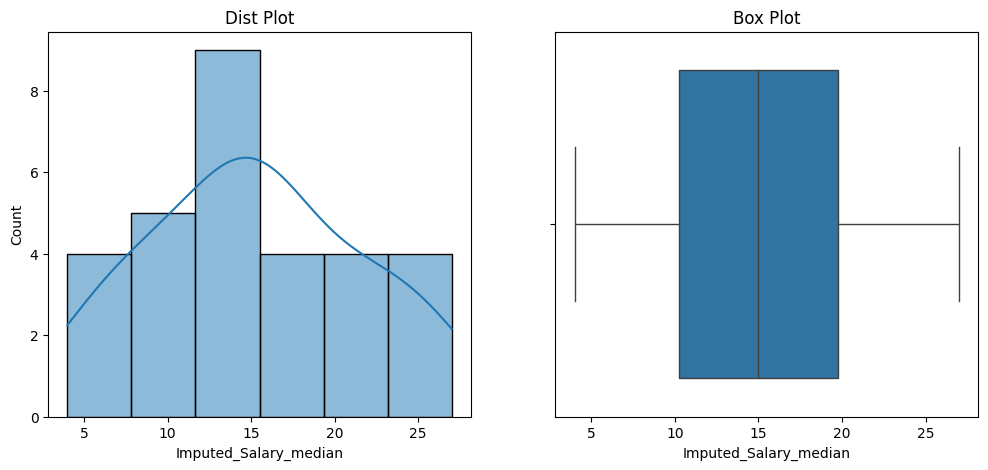

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Imputed_Salary_median'],kde=True)
plt.title('Dist Plot')

plt.subplot(1,2,2)
sns.boxplot(data=df,x ='Imputed_Salary_median')
plt.title('Box Plot')
plt.show()

In [23]:
#Capping
lower_cap=df['Salary'].quantile(0.05) # Lower Cap is 5th Percentile
upper_cap=df['Salary'].quantile(0.95) # Upper Cap is 95th percentile


In [24]:
lower_cap

np.float64(-9.199999999999996)

In [25]:
upper_cap

np.float64(45.149999999999906)

In [26]:
# if df['Salary']<lower_cap,lower_cap ,this conditions satistify then Lower cap
#if this df['Salary']>upper_cap,upper_cap,df['Salary']) condition Satisfy the Upper cap
# otherwise keep salary has it is.
df['Salary_Capped']=np.where(df['Salary']<lower_cap,lower_cap,
        np.where(df['Salary']>upper_cap,upper_cap,df['Salary']))

In [27]:
df

,Salary,Salary_imputed_mean,Imputed_Salary_median,Salary_Capped
0,-30,16.066667,15.0,-9.20
1,-20,16.066667,15.0,-9.20
2,4,4.000000,4.0,4.00
3,5,5.000000,5.0,5.00
4,6,6.000000,6.0,6.00
5,7,7.000000,7.0,7.00
6,8,8.000000,8.0,8.00
7,9,9.000000,9.0,9.00
8,10,10.000000,10.0,10.00
9,10,10.000000,10.0,10.00


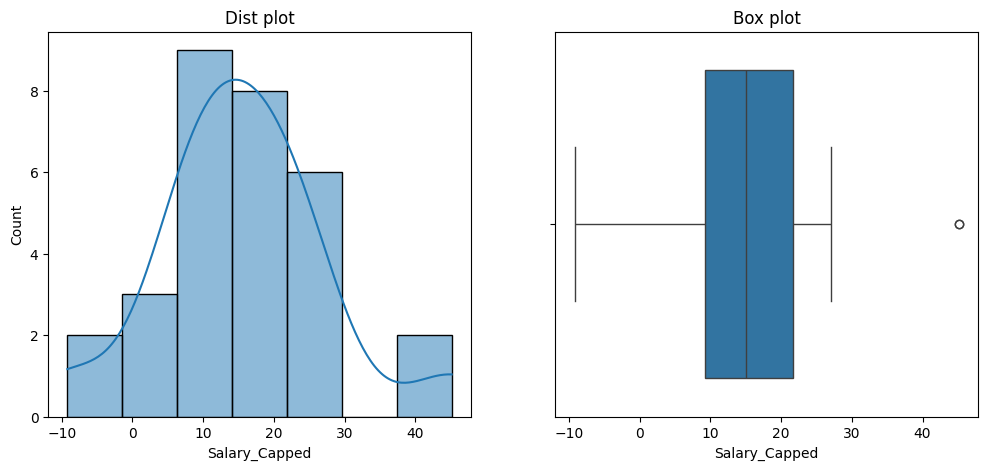

In [29]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Salary_Capped'],kde=True)
plt.title('Dist plot')

plt.subplot(1,2,2)
sns.boxplot(data = df, x='Salary_Capped')
plt.title('Box plot')
plt.show()